In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import utils.helpers as hlp
from samplers.dpsgld import BayesianRegressionDPSGLD
from samplers.mysgld import BayesianRegressionMYSGLD

## Synthetic Data Generation

In [2]:
def generate_synthetic_data(n_data, noise_std=0.5):
    """
    Generate synthetic data for the model: y = 1 + x + ε, where ε ~ N(0, noise_std)
    
    Parameters:
        n_data    : int, number of data points (default: 10000)
        noise_std : float, standard deviation of the noise (default: 0.5)
    
    Returns:
        X : numpy array of shape (n_data, 2)  [intercept column + x]
        y : numpy array of shape (n_data,)
    """
    x = rng.random(n_data)
    epsilon = rng.normal(0, noise_std, n_data)
    y = 1.0 + x + epsilon
    X = np.column_stack((np.ones(n_data), x))
    return X, y

seed = 42
rng = np.random.default_rng(seed)
n_data = 10000
X, y = generate_synthetic_data(n_data)

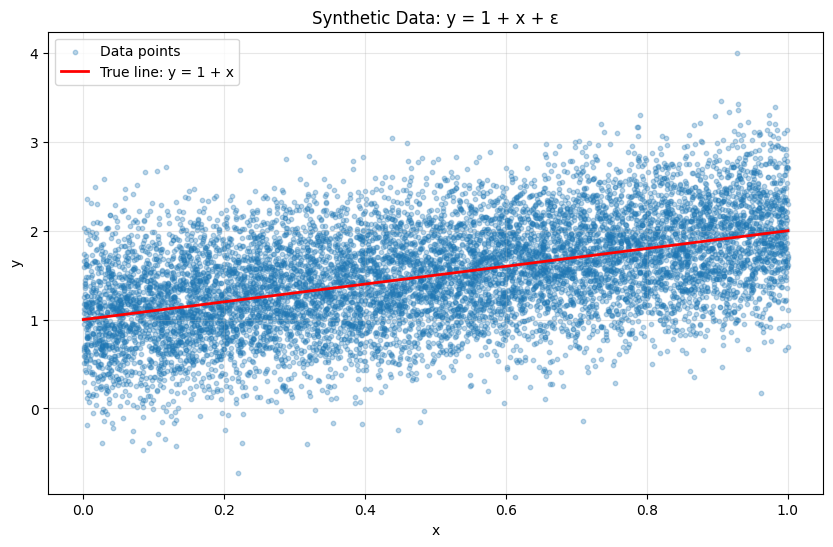

In [3]:
# Scatter plot: x vs y
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 1], y, alpha=0.3, s=10, label='Data points')   # X[:, 1] is the x values
# Plot the true regression line
x_line = np.linspace(0, 1, 100)
y_true = 1.0 + x_line
plt.plot(x_line, y_true, 'r-', linewidth=2, label='True line: y = 1 + x')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Data: y = 1 + x + ε')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## True $\mathbf{\beta}\in \mathbb R^2$ and OLS $\mathbf{\beta}_*\in \mathbb R^2$

In [4]:
beta_star = np.array([1.0, 1.0])  # True parameters
beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
print("OLS estimate:", beta_ols)

OLS estimate: [1.00899339 0.996037  ]


## Prior Distribution of $\mathbf{\beta}\in \mathbb R^2$

Plot of the prior distribution


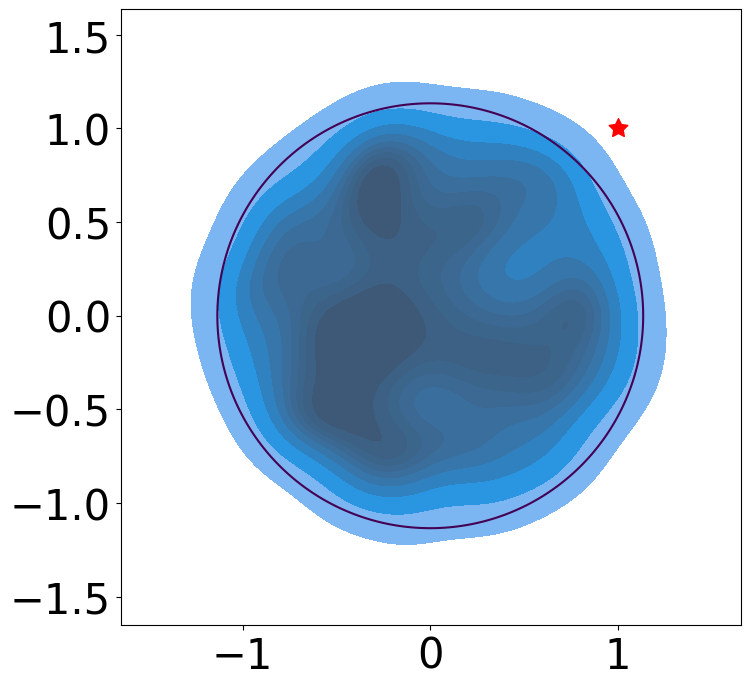

In [5]:
# Get the prior distribution
lp = 2 
s = 0.8 * np.linalg.norm(beta_ols, ord=lp)
prior_dist = hlp.priors(
    dim=X.shape[1], N=1000, s=s, lp=lp, rng=rng
)
# Plot the prior distribution
print("Plot of the prior distribution")
beta_x = prior_dist.T[0]
beta_y = prior_dist.T[1]
X1 = np.linspace(-1.5, 1.5, 1000)
Y = np.linspace(-1.5, 1.5, 1000)
xx, yy = np.meshgrid(X1, Y)
zz = np.power(
    np.power(np.abs(xx), lp) + np.power(np.abs(yy), lp), 1/lp
)
fig = plt.figure(figsize=(8,8))
plt.contour(X1, Y, zz, [s])
sns.kdeplot(
    x=beta_x, y=beta_y, fill=True, levels=10
)
plt.scatter(beta_star[0], beta_star[1], c='r', s=200, marker=(5,1))
plt.tick_params(labelsize=30)
plt.savefig('images/linreg_2d_prior.png')
plt.show()

## Sampling of the posterior of $\beta\in\R^2$

In [6]:
n_samples = 300
n_iters = 500
n_agents = 20
eta = 5e-4
gamma = 1e-3
sigma = 0.5
type = 'linear'
batch = 100

### Samples from MYSGLD

100%|██████████| 500/500 [00:32<00:00, 15.42it/s]


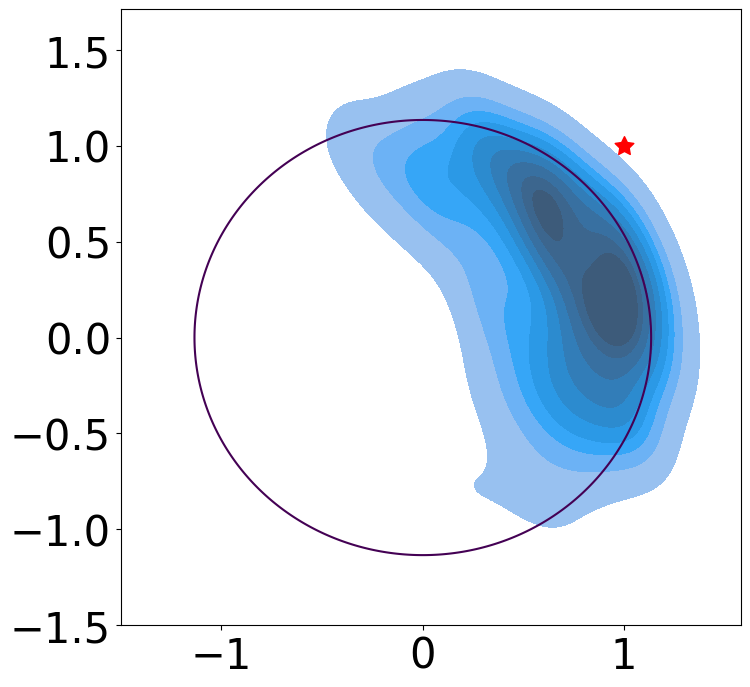

In [7]:
mysgld_model = BayesianRegressionMYSGLD(
    X=X, y=y, s=s, lp=lp, n_samples=n_samples, n_iters=n_iters,
    eta=eta, gamma=gamma, type=type, batch=batch, sigma=sigma,
    seed=seed
)
mysgld_chain = mysgld_model.sample_parameters()
beta_xs=mysgld_chain[-1, 0, :]
beta_ys=mysgld_chain[-1, 1, :]
plt.figure(figsize=(8,8))
plt.contour(X1, Y, zz, [s])
sns.kdeplot(
    x=beta_xs, y=beta_ys, fill=True, levels=10
)
plt.scatter(beta_star[0], beta_star[1], c='r', s=200, marker=(5,1))
plt.tick_params(labelsize=30)
plt.savefig('images/linreg_2d_posterior_mysgld.png')
plt.show()

### Samples from DPSGLD

100%|██████████| 500/500 [13:08<00:00,  1.58s/it]


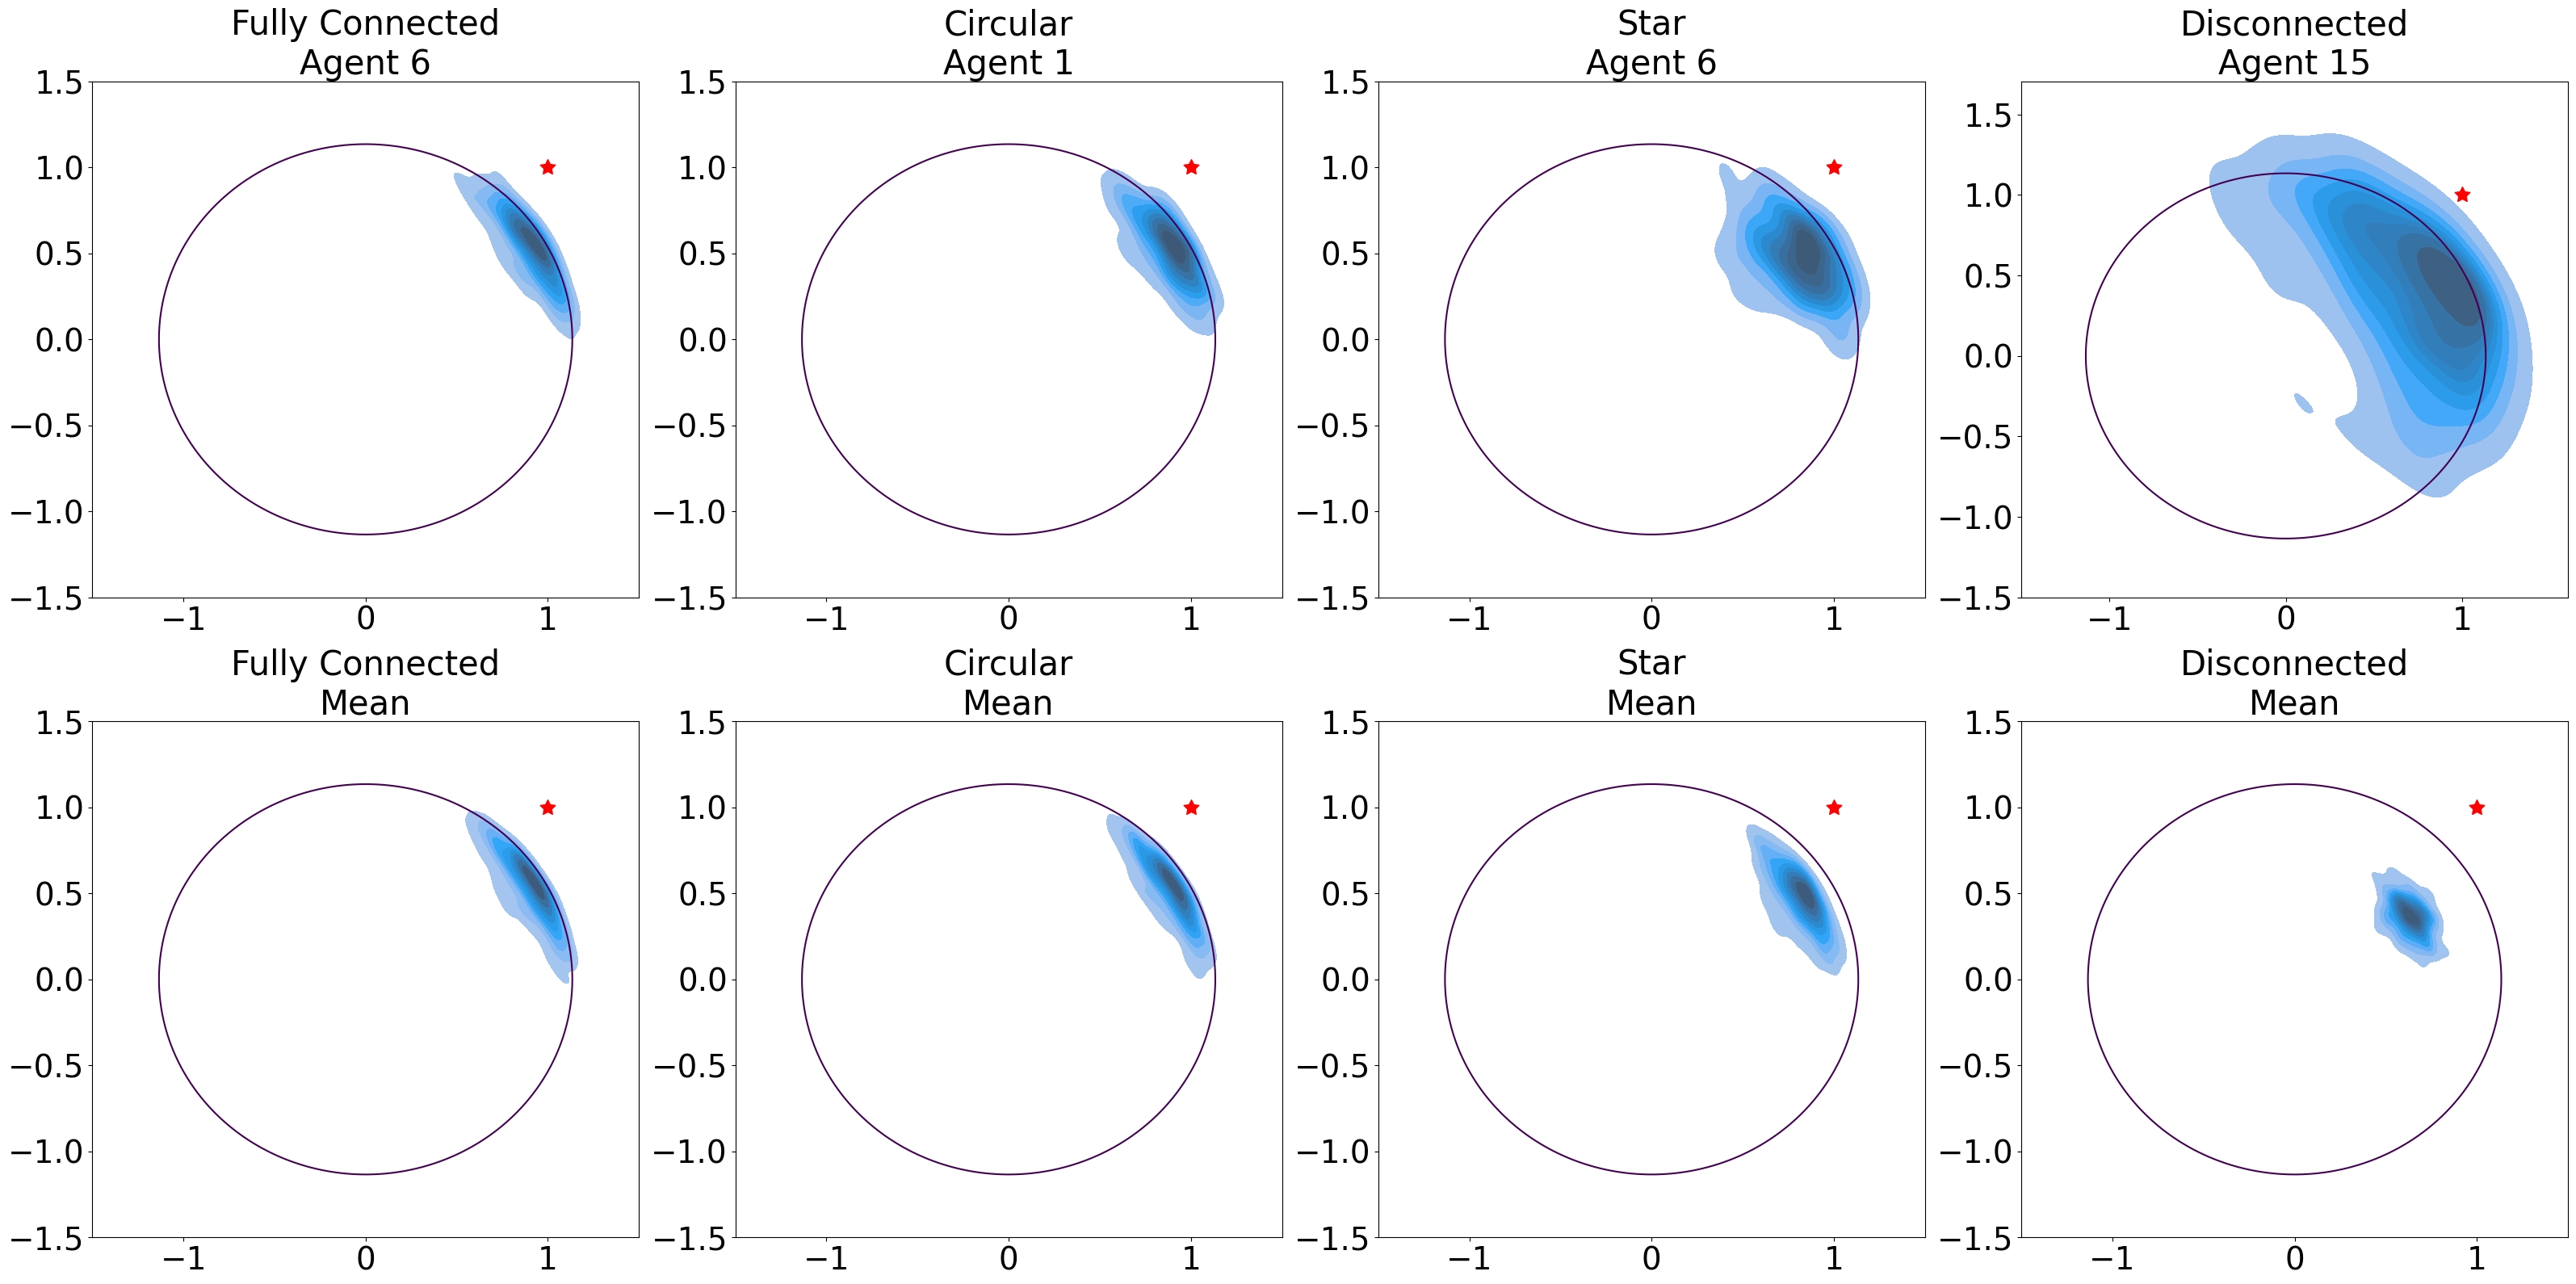

In [8]:
def sampling_posterior(
    X=X, y=y, n_samples=100, n_agents=10, eta=5e-5,
    gamma=1e-2, lp=2, s=0.8, n_iters=500,
    sigma=1.0, type='linear', batch=100,
    nets=("fcn", "cn", "sn", "fdn"),
    beta_star=beta_star, seed=seed
):
    fig, axes = plt.subplots(2,4, figsize=(32,16), sharey=False)
    network_names = ["Fully Connected", "Circular", "Star", "Disconnected"]
    
    for i, (net, name) in enumerate(zip(nets, network_names)):
        ax_top = axes[0, i]
        ax_bottom = axes[1, i]
        model = BayesianRegressionDPSGLD(
            X=X, y=y, s=s, lp=lp, n_agents=n_agents, n_samples=n_samples,
            n_iters=n_iters, eta=eta, gamma=gamma, sigma=sigma,
            type=type, net=net, batch=batch, seed=seed
        )
        history_all_agents, Beta_mean_all_agents = model.sample_parameters()
        ax_top.contour(X1, Y, zz, [s])
        random_agent = rng.integers(0, n_agents)
        sns.kdeplot(
            x=history_all_agents[-1, random_agent, 0, :],
            y=history_all_agents[-1, random_agent, 1, :],
            fill=True, levels=10, ax=ax_top
        )
        ax_top.scatter(
            beta_star[0], beta_star[1],
            c='r', s=200, marker=(5,1)
        )
        ax_top.set_title(f"{name}\nAgent {random_agent}", fontsize=30)
        ax_top.tick_params(axis="both", labelsize=28)
        
        ax_bottom.contour(X1, Y, zz, [s])
        sns.kdeplot(
            x=Beta_mean_all_agents[-1, 0, :], y=Beta_mean_all_agents[-1, 1, :],
            fill=True, levels=10, ax=ax_bottom
        )
        ax_bottom.scatter(
            beta_star[0], beta_star[1],
            c='r', s=200, label='OLS', marker=(5,1)
        )
        ax_bottom.set_title(f"{name}\nMean", fontsize=30)
        ax_bottom.tick_params(axis="both", labelsize=28)
    plt.tight_layout()
    plt.savefig('images/linreg_2d_posterior_dpsgld.png')
    plt.show()

sampling_posterior(
    X=X, y=y, n_samples=n_samples, n_agents=n_agents, 
    eta=eta, gamma=gamma, lp=lp, s=s, n_iters=n_iters,
    sigma=sigma, type=type, batch=batch,
    nets=("fcn","cn", "sn", "fdn"),
    beta_star=beta_star, seed=seed
)